In [1]:
import sys, warnings
sys.path.insert(0, '/Users/advik/ice-top')
warnings.filterwarnings('ignore')

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from antarctic.config import REGION_NAMES, DATA_DIR
from antarctic.elevation import default_elevation
from antarctic.regions import regions_ant2k, regions_at
from antarctic.datasets import load_era5, load_bromwich, load_ice_cores, load_aws
from antarctic.analysis import trend_1d, trend_map, merge_neighbours, pca_fields
from antarctic.helpers import ann_block_ave
from antarctic.maps import (PLATE, polar_axes, add_coast, surfm, scatterm,
                            cmocean_like, region_cmap, region_legend)

plt.rcParams['figure.dpi'] = 110
print('data dir:', DATA_DIR)


data dir: /Users/advik/Downloads/Mathieu/Data


In [2]:
elev = default_elevation()
print(elev.name)

known = {'South Pole': (-89.99, 0.0, 2835), 'Dome C': (-75.10, 123.35, 3233),
         'WAIS Divide': (-79.47, -112.09, 1766), 'Vostok': (-78.47, 106.84, 3488),
         'Dome A': (-80.37, 77.37, 4093), 'Byrd': (-80.01, -119.32, 1530),
         'Talos Dome': (-72.78, 159.07, 2315), 'Law Dome': (-66.77, 112.81, 1370)}

pd.DataFrame([{'site': k, 'interpolated_m': round(float(elev(la, lo)), 1),
               'reference_m': ref, 'diff_m': round(float(elev(la, lo)) - ref, 1)}
              for k, (la, lo, ref) in known.items()]).set_index('site')


Bromwich WRF HGT (60 km)


,interpolated_m,reference_m,diff_m
site,,,
South Pole,2832.5,2835,-2.5
Dome C,3217.9,3233,-15.1
WAIS Divide,1766.8,1766,0.8
Vostok,3456.1,3488,-31.9
Dome A,3971.5,4093,-121.5
Byrd,1520.2,1530,-9.8
Talos Dome,2155.3,2315,-159.7
Law Dome,742.3,1370,-627.7


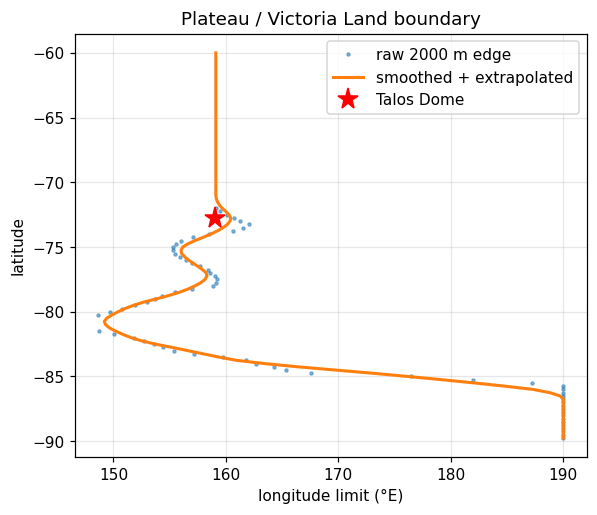

In [3]:
from scripts.make_victoria_limit import (plateau_edge_longitude, fill_north,
                                         smooth, LAT_STEP, SMOOTH_WINDOW,
                                         LON_MIN, LON_MAX)

lats_v = np.arange(-89.75, -59.99, LAT_STEP)
raw = np.array([plateau_edge_longitude(elev, la) for la in lats_v])
lim = np.clip(smooth(fill_north(raw), SMOOTH_WINDOW), LON_MIN, LON_MAX)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(raw, lats_v, '.', ms=4, alpha=.5, label='raw 2000 m edge')
ax.plot(lim, lats_v, '-', lw=2, label='smoothed + extrapolated')
ax.plot(159.07, -72.78, 'r*', ms=14, label='Talos Dome')
ax.set_xlabel('longitude limit (°E)'); ax.set_ylabel('latitude')
ax.set_title('Plateau / Victoria Land boundary'); ax.legend(); ax.grid(alpha=.3)
plt.show()


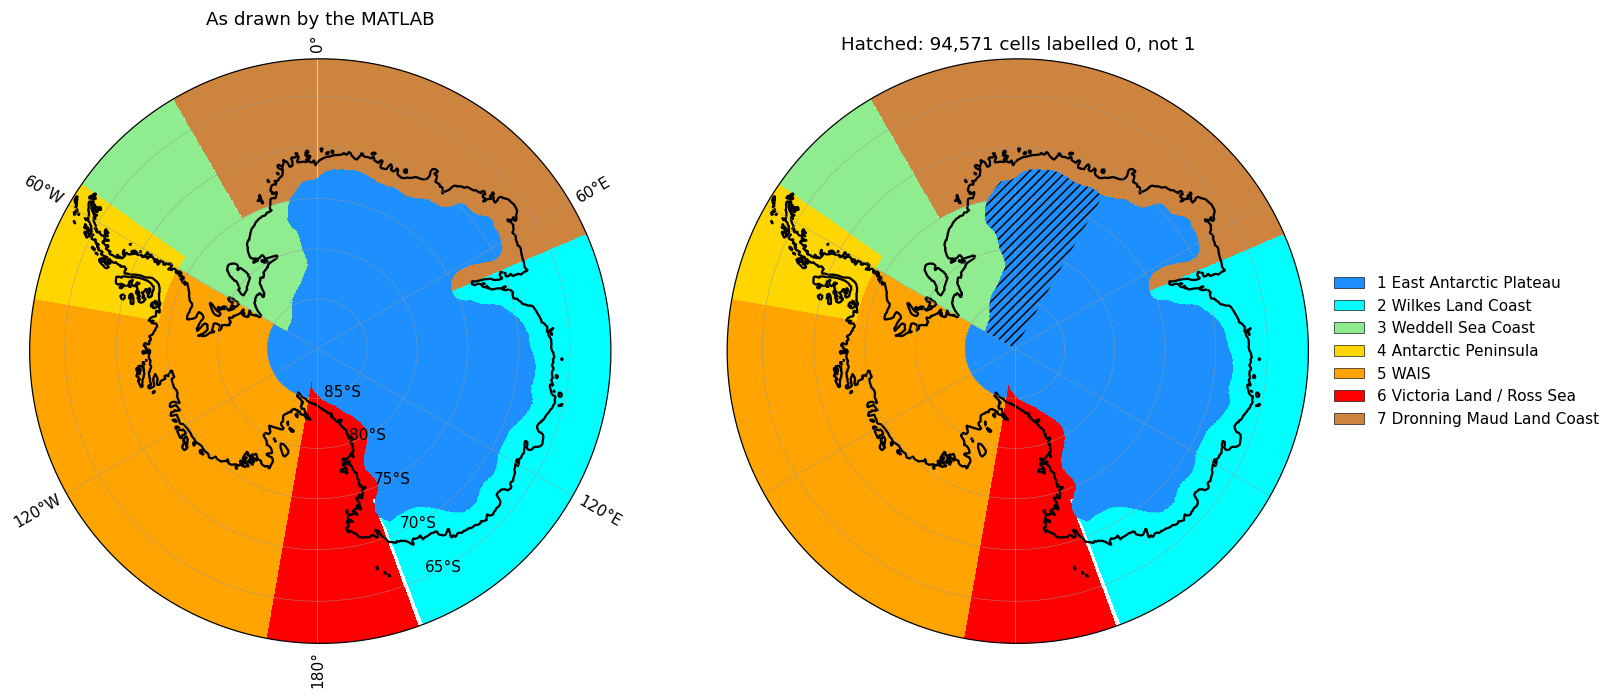

region-0 land cells: 94,571  (22% of the plateau)


In [4]:
lat_g = np.arange(-90.0, -59.95, 0.1)
lon_g = np.arange(0.0, 360.05, 0.1)
LA, LO = np.meshgrid(lat_g, lon_g, indexing='ij')
Z = elev(LA, LO)

ri_raw = regions_ant2k(LA, LO, Z, edml_zero=True)    # faithful to the MATLAB
ri_fix = regions_ant2k(LA, LO, Z, edml_zero=False)   # corrected
cmap, norm = region_cmap()

fig = plt.figure(figsize=(15, 7.5))
_, ax1 = polar_axes(fig, (1, 2, 1), lat_max=-61.0)
surfm(ax1, lat_g, lon_g, np.where(ri_raw == 0, 1.0, ri_raw), cmap=cmap, norm=norm)
add_coast(ax1); ax1.set_title('As drawn by the MATLAB')

_, ax2 = polar_axes(fig, (1, 2, 2), lat_max=-61.0, labels=False)
surfm(ax2, lat_g, lon_g, ri_fix, cmap=cmap, norm=norm)
ax2.contourf(lon_g, lat_g, np.where(ri_raw == 0, 1.0, np.nan), levels=[.5, 1.5],
             colors='none', hatches=['////'], transform=PLATE, zorder=4)
add_coast(ax2)
n0 = int(np.sum((ri_raw == 0) & (Z > 10)))
ax2.set_title(f'Hatched: {n0:,} cells labelled 0, not 1')
region_legend(ax2)
plt.show()

print(f'region-0 land cells: {n0:,}  '
      f'({n0 / np.sum((ri_fix == 1) & (Z > 10)):.0%} of the plateau)')


In [5]:
sites = {'Dome C': (-75.10, 123.35), 'Vostok': (-78.47, 106.84),
         'South Pole': (-89.99, 0.0), 'EDML/Kohnen': (-75.00, 0.07),
         'Talos Dome': (-72.78, 159.07), 'Byrd': (-80.01, -119.32),
         'Law Dome': (-66.77, 112.81), 'James Ross Is': (-64.20, -57.68),
         'Berkner Is': (-79.55, -45.68), 'Taylor Dome': (-77.78, 158.72),
         'Neumayer': (-70.65, -8.25), 'Dumont d\'Urville': (-66.66, 140.00)}

rows = []
for name, (la, lo) in sites.items():
    r_raw = regions_at(la, lo, edml_zero=True)[0]
    r_fix = regions_at(la, lo, edml_zero=False)[0]
    rows.append({'site': name, 'matlab': r_raw, 'corrected': r_fix,
                 'region': REGION_NAMES.get(r_fix, '?')})
pd.DataFrame(rows).set_index('site')


,matlab,corrected,region
site,,,
Dome C,1.0,1.0,East Antarctic Plateau
Vostok,1.0,1.0,East Antarctic Plateau
South Pole,0.0,1.0,East Antarctic Plateau
EDML/Kohnen,0.0,1.0,East Antarctic Plateau
Talos Dome,1.0,1.0,East Antarctic Plateau
Byrd,5.0,5.0,WAIS
Law Dome,2.0,2.0,Wilkes Land Coast
James Ross Is,4.0,4.0,Antarctic Peninsula
Berkner Is,3.0,3.0,Weddell Sea Coast


In [6]:
era5 = load_era5()
print(era5.attrs['note'])
m = era5.mean('time')

check = {'Dumont d\'Urville': (-66.7, 140.0, -11), 'Halley': (-75.35, 333.6, -18),
         'South Pole': (-90, 0, -49), 'Vostok': (-78.5, 106.9, -55),
         'Dome C': (-75.1, 123.35, -54)}
pd.DataFrame([{'site': k, 'file_degC': round(float(m.sel(lat=la, lon=lo, method='nearest')), 1),
               'true_annual_mean': tru,
               'error': round(float(m.sel(lat=la, lon=lo, method='nearest')) - tru, 1)}
              for k, (la, lo, tru) in check.items()]).set_index('site')


ERA5 t at 1000 hPa (not 2 m); latitude limited to 55S-90S


,file_degC,true_annual_mean,error
site,,,
Dumont d'Urville,-10.0,-11,1.0
Halley,-13.4,-18,4.6
South Pole,-24.0,-49,25.0
Vostok,-22.9,-55,32.1
Dome C,-20.7,-54,33.3


(85, 141, 1440) 1940-2024, NaN fraction 0.000


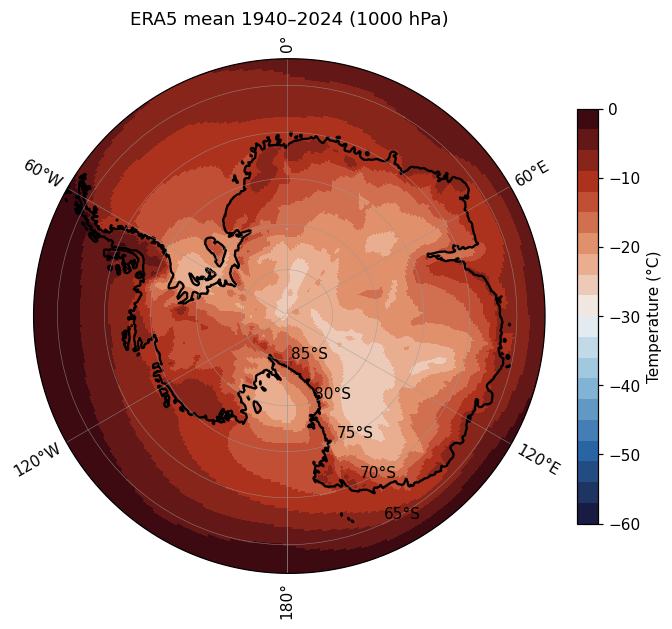

In [7]:
ann = era5.groupby('time.year').mean('time')
years = ann.year.values.astype(float)
lat_e, lon_e = ann.lat.values, ann.lon.values
cube = ann.values.astype('float32')
print(cube.shape, f'{years[0]:.0f}-{years[-1]:.0f}, NaN fraction {np.isnan(cube).mean():.3f}')

fig = plt.figure(figsize=(7.5, 7))
_, ax = polar_axes(fig, 111, lat_max=-62.0)
mesh = surfm(ax, lat_e, lon_e, np.nanmean(cube, axis=0),
             cmap=cmocean_like('balance', 20), vmin=-60, vmax=0)
add_coast(ax); fig.colorbar(mesh, ax=ax, shrink=.7, label='Temperature (°C)')
ax.set_title('ERA5 mean 1940–2024 (1000 hPa)')
plt.show()


In [8]:
YEAR_START, YEAR_STOP, TREND_LIM = 1980, 2020, 0.65
stations = load_aws()

aws = []
for st in stations:
    slope, p, n = trend_1d(st.year, st.temp, YEAR_START, YEAR_STOP)
    aws.append({'station': st.name, 'lat': st.lat, 'lon': st.lon,
                'trend_C_per_dec': round(10 * slope, 3), 'p': round(p, 3), 'n': n})
aws = pd.DataFrame(aws).set_index('station')
aws['sig'] = aws.p < 0.05
aws.sort_values('trend_C_per_dec', ascending=False)


,lat,lon,trend_C_per_dec,p,n,sig
station,,,,,,
FaradayVernadsky,-65.14,-64.15,0.339,0.020,40,True
Rothera,-67.34,-68.08,0.318,0.063,40,False
AmundsenScott,-90.00,0.00,0.312,0.012,40,True
McMurdo,-77.90,166.70,0.256,0.053,40,False
Marambio,-64.24,-56.63,0.230,0.186,40,False
Vostok,-78.50,106.90,0.189,0.180,37,False
Bellingshausen,-62.12,-58.58,0.117,0.283,40,False
Mawson,-67.60,62.90,0.104,0.320,40,False
Davis,-68.60,78.00,0.061,0.642,40,False


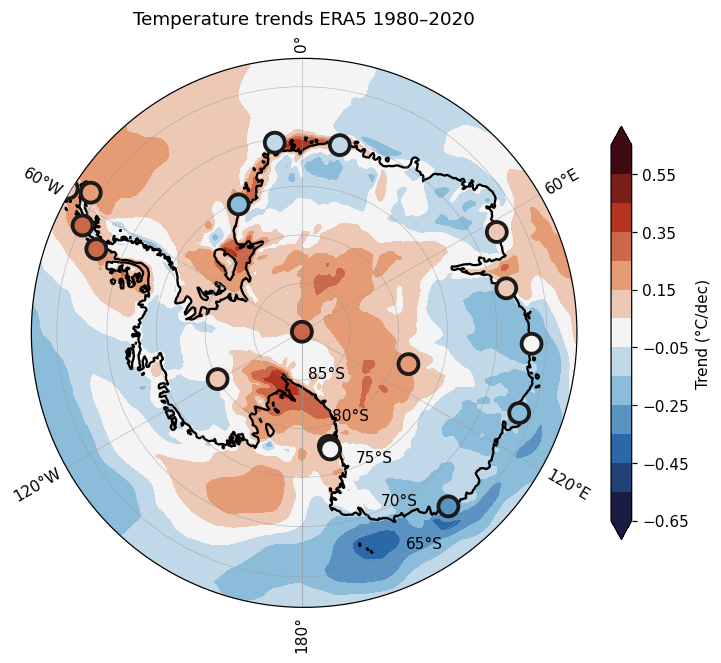

In [17]:
LEV = np.arange(-0.65, 0.66, 0.1)          # the reference's discrete levels
cmap_t = cmocean_like('balance', 13)
slope_e, pval_e = trend_map(years, cube, YEAR_START, YEAR_STOP)

fig = plt.figure(figsize=(8, 7.5))
_, ax = polar_axes(fig, 111, lat_max=-62.0)
mesh = ax.contourf(lon_e, lat_e, 10 * slope_e, levels=LEV, cmap=cmap_t,
                   extend='both', transform=PLATE)
scatterm(ax, aws.lat, aws.lon, s=170, c=aws.trend_C_per_dec, cmap=cmap_t,
         vmin=-0.65, vmax=0.65, edgecolors='0.1', linewidths=2.5)
add_coast(ax)
fig.colorbar(mesh, ax=ax, shrink=.65, label='Trend (°C/dec)', ticks=LEV[::2])
ax.set_title(f'Temperature trends ERA5 {YEAR_START}–{YEAR_STOP}')
plt.show()


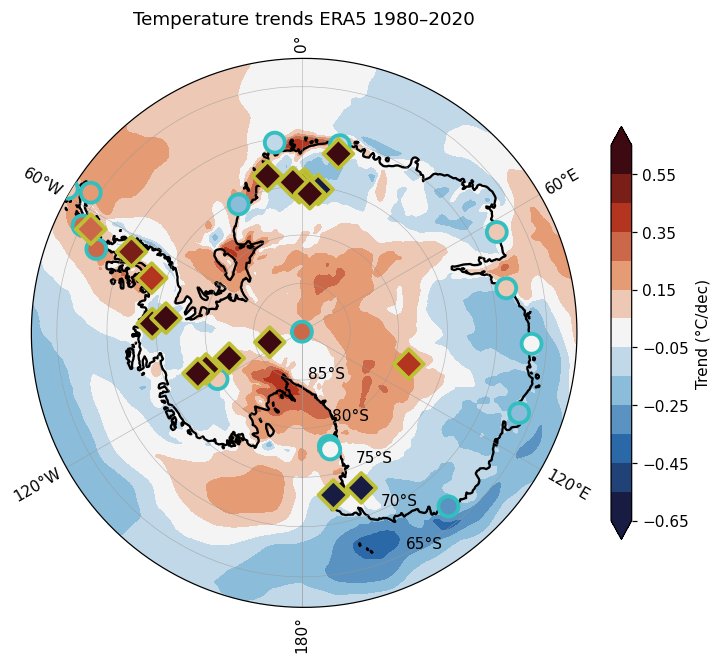

In [18]:
sig = np.isfinite(pval_c) & (pval_c < 0.05)

fig = plt.figure(figsize=(8, 7.5))
_, ax = polar_axes(fig, 111, lat_max=-62.0)
mesh = ax.contourf(lon_e, lat_e, 10 * slope_e, levels=LEV, cmap=cmap_t,
                   extend='both', transform=PLATE)
add_coast(ax)
# stations: cyan edge, from MATLAB line 422
scatterm(ax, aws.lat, aws.lon, s=170, c=aws.trend_C_per_dec, cmap=cmap_t,
         vmin=-0.65, vmax=0.65, edgecolors=[(0.2, 0.75, 0.75)], linewidths=2.5)
# ice cores: yellow edge, diamonds, from MATLAB line 145
scatterm(ax, cores.lat[sig], cores.lon[sig], s=190, marker='D',
         c=10 * slope_c[sig], cmap=cmap_t, vmin=-0.65, vmax=0.65,
         edgecolors=[(0.75, 0.75, 0.2)], linewidths=2.5)
fig.colorbar(mesh, ax=ax, shrink=.65, label='Trend (°C/dec)', ticks=LEV[::2])
ax.set_title(f'Temperature trends ERA5 {YEAR_START}–{YEAR_STOP}')
plt.show()


78 cores → 33 groups (largest 18, 15 actually merged)
15/33 groups p<0.05


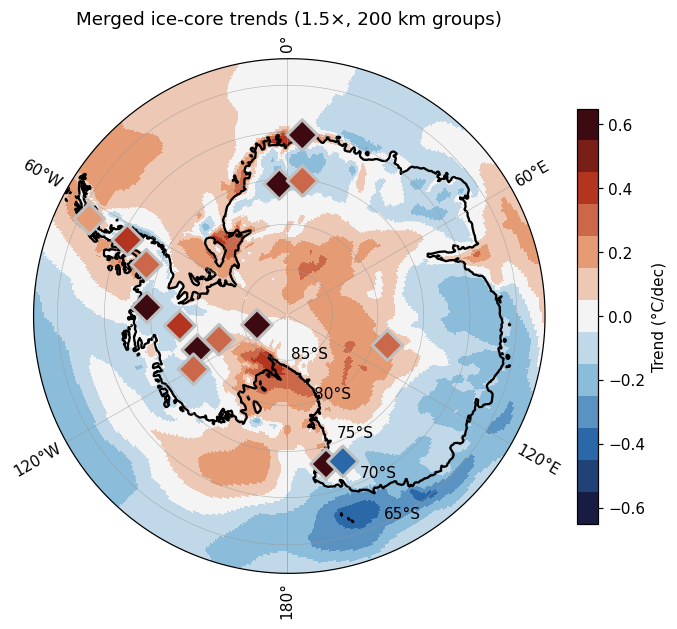

In [11]:
g = merge_neighbours(cores.age, cores.d18O, cores.lat, cores.lon, threshold_km=200.0)
sizes = [len(m) for m in g['members']]
print(f"{len(cores)} cores → {len(g['age'])} groups "
      f"(largest {max(sizes)}, {sum(1 for s in sizes if s > 1)} actually merged)")

sm = np.array([trend_1d(a, np.asarray(v) * 1.5, CORE_START, CORE_STOP)[:2]
               for a, v in zip(g['age'], g['value'])])
slope_m, pval_m = sm[:, 0], sm[:, 1]
sig_m = np.isfinite(pval_m) & (pval_m < 0.05)
print(f'{sig_m.sum()}/{len(slope_m)} groups p<0.05')

fig = plt.figure(figsize=(7.5, 7))
_, ax = polar_axes(fig, 111, lat_max=-62.0)
mesh = surfm(ax, lat_e, lon_e, 10 * slope_e, cmap=cmap_t, vmin=-TREND_LIM, vmax=TREND_LIM)
scatterm(ax, g['lat'][sig_m], g['lon'][sig_m], s=200, c=10 * slope_m[sig_m], marker='D',
         cmap=cmap_t, vmin=-TREND_LIM, vmax=TREND_LIM, edgecolors='0.75', linewidths=2)
add_coast(ax); fig.colorbar(mesh, ax=ax, shrink=.7, label='Trend (°C/dec)')
ax.set_title('Merged ice-core trends (1.5×, 200 km groups)')
plt.show()


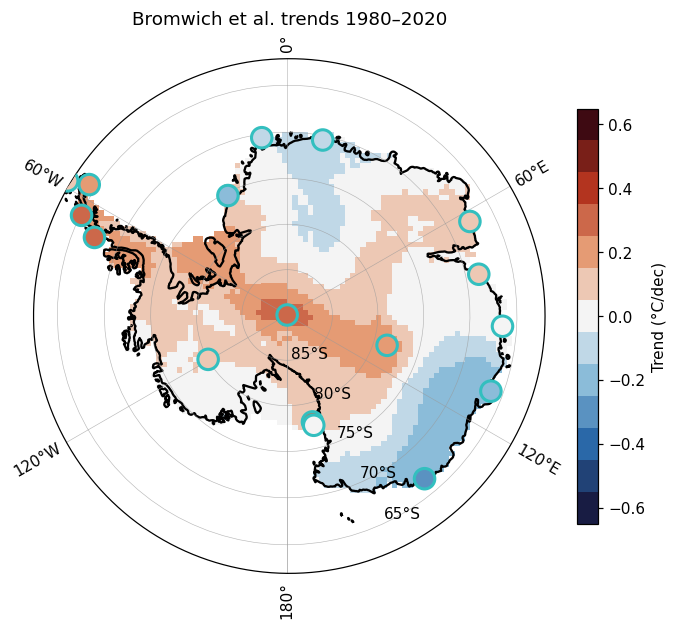

In [12]:
ds_b = load_bromwich()
ann_b = ds_b['RECON'].groupby('time.year').mean('time')
slope_b, pval_b = trend_map(ann_b.year.values.astype(float),
                            ann_b.values.astype('float32'), YEAR_START, YEAR_STOP)
land = ds_b['LANDMASK'].values > 0.5
slope_bm = np.where(land, slope_b, np.nan)

fig = plt.figure(figsize=(7.5, 7))
_, ax = polar_axes(fig, 111, lat_max=-62.0)
mesh = ax.pcolormesh(ds_b['lon'].values, ds_b['lat'].values, 10 * slope_bm,
                     cmap=cmap_t, vmin=-TREND_LIM, vmax=TREND_LIM,
                     transform=PLATE, shading='auto')
scatterm(ax, aws.lat, aws.lon, s=180, c=aws.trend_C_per_dec, cmap=cmap_t,
         vmin=-TREND_LIM, vmax=TREND_LIM, edgecolors=(.2, .75, .75), linewidths=2)
add_coast(ax); fig.colorbar(mesh, ax=ax, shrink=.7, label='Trend (°C/dec)')
ax.set_title(f'Bromwich et al. trends {YEAR_START}–{YEAR_STOP}')
plt.show()


PC1 19.6%  PC2 16.6%  PC3 14.0%
  18 PCs reach 90%
  28 PCs reach 95%
  56 PCs reach 99%


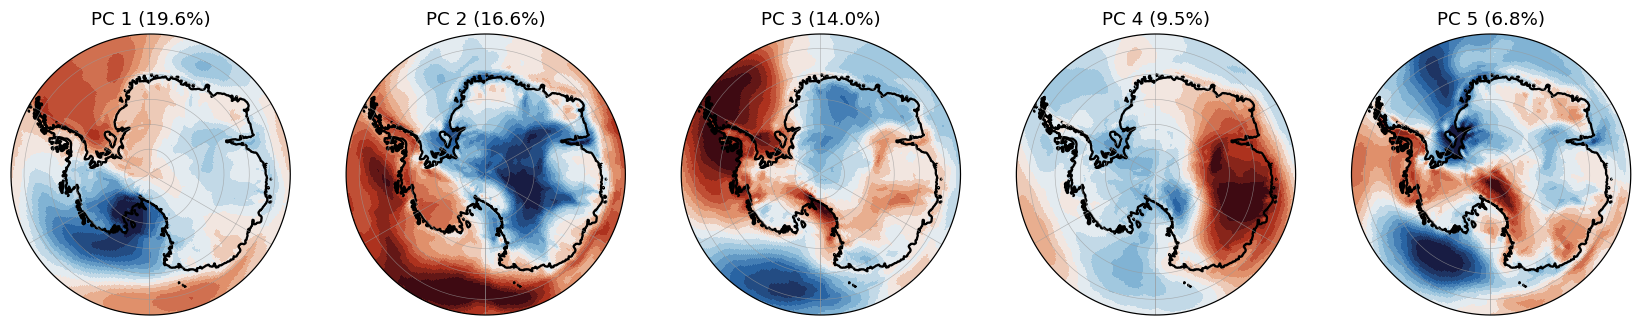

In [13]:
res = pca_fields(cube, n_components=min(80, cube.shape[0]))
exp, cum = res['explained'], res['cumulative']
print(f'PC1 {exp[0]:.1f}%  PC2 {exp[1]:.1f}%  PC3 {exp[2]:.1f}%')
for t in (90, 95, 99):
    print(f'  {int(np.searchsorted(cum, t) + 1)} PCs reach {t}%')

fig = plt.figure(figsize=(19, 4.4))
for i in range(5):
    _, ax = polar_axes(fig, (1, 5, i + 1), lat_max=-62.0, labels=False)
    v = res['score'][i]
    lim = np.nanpercentile(np.abs(v), 99)
    surfm(ax, lat_e, lon_e, v, cmap=cmocean_like('balance', 20), vmin=-lim, vmax=lim)
    add_coast(ax); ax.set_title(f'PC {i+1} ({exp[i]:.1f}%)')
plt.show()


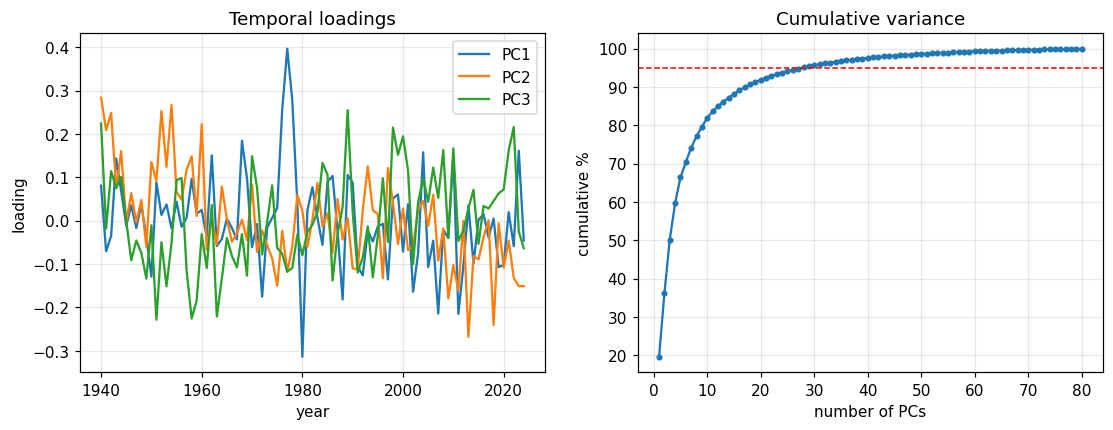

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for i in range(3):
    axs[0].plot(years, res['coeff'][:, i], label=f'PC{i+1}')
axs[0].set_xlabel('year'); axs[0].set_ylabel('loading')
axs[0].set_title('Temporal loadings'); axs[0].legend(); axs[0].grid(alpha=.3)
axs[1].plot(np.arange(1, len(cum) + 1), cum, 'o-', ms=3)
axs[1].axhline(95, color='r', ls='--', lw=1)
axs[1].set_xlabel('number of PCs'); axs[1].set_ylabel('cumulative %')
axs[1].set_title('Cumulative variance'); axs[1].grid(alpha=.3)
plt.show()


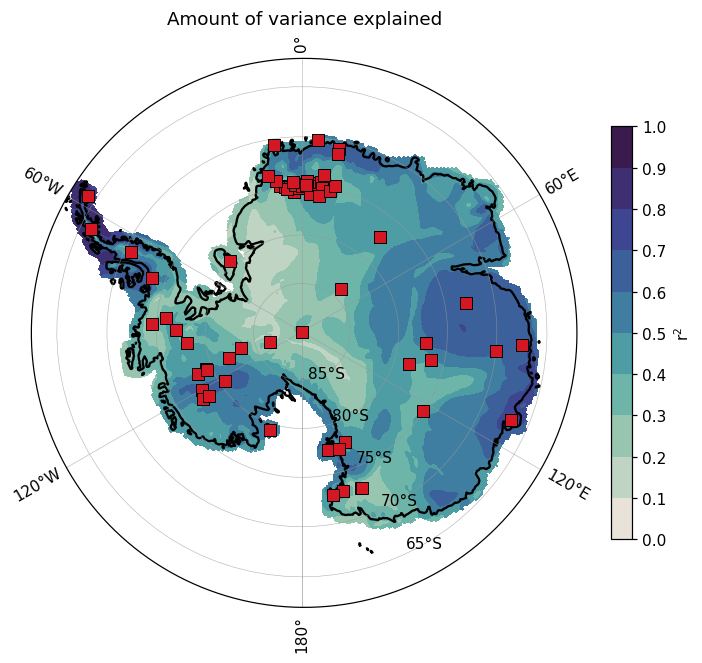

median r² over land = 0.37  (range 0.11–0.87)


In [19]:
LA_e, LO_e = np.meshgrid(lat_e, lon_e, indexing='ij')
land = elev(LA_e, LO_e) > 10          # continent mask

fig = plt.figure(figsize=(8, 7.5))
_, ax = polar_axes(fig, 111, lat_max=-62.0)
mesh = ax.contourf(lon_e, lat_e, np.where(land, r2, np.nan),
                   levels=np.arange(0, 1.01, 0.1),
                   cmap=cmocean_like('rain', 10), transform=PLATE)
add_coast(ax)
scatterm(ax, cores.lat, cores.lon, s=55, marker='s',
         c=[(212/255, 23/255, 35/255)], edgecolors='k', linewidths=.6)
fig.colorbar(mesh, ax=ax, shrink=.65, label='r$^2$', ticks=np.arange(0, 1.01, .1))
ax.set_title('Amount of variance explained')
plt.show()

print(f'median r² over land = {np.nanmedian(r2[land]):.2f}  '
      f'(range {np.nanmin(r2[land]):.2f}–{np.nanmax(r2[land]):.2f})')


In [16]:
from antarctic.datasets import load_paleo_ldc
try:
    dataPALEO, dataLDC = load_paleo_ldc()
    print('found it — extend this cell')
except FileNotFoundError as e:
    print('SKIPPED:', e)


SKIPPED: /Users/advik/Downloads/Mathieu/Data/dataPALEO_LDC.mat is missing. It is not in the Mathieu delivery (Data/ has only the ERA5, Bromwich, ice-core and AWS files). The 'Add New ice cores from the team' section cannot be reproduced without it.
